Air resistance motion

Consider the set of coupled second-order ODE's below which model mechanical motion under drag <span style="color: red;">and</span>
air resistance in this case. This model can be interpreted as crudely describing long-distance jumping, with a purely opposed drag force for motion in positive x-direction and drag and gravity influencing motion in z-direction. Let the drag-coefficient, $k$, be a function of coordinates, separately for the x-motion and z-motion. This is meant to describe the dynamics of a long-distance jumper changing posture after lift-off, generally reducing drag in positive x-direction, the jump distance, and increasing drag in negative z-direction, staying in the air for as long as possible.


$$\frac{d^{2}x}{dt^{2}} = -k_{x}(x)\,\frac{dx}{dt}\,\sqrt{\left(\frac{dx}{dt}\right)^{2}+\left(\frac{dz}{dt}\right)^{2}}$$
$$\frac{d^{2}z}{dt^{2}} = -g-k_{z}(z)\,\frac{dz}{dt}\,\sqrt{\left(\frac{dx}{dt}\right)^{2}+\left(\frac{dz}{dt}\right)^{2}}.$$

The functions $k_{x,z}$ parametrize the change of the drag coefficient as function of x- and z-coordinates, respectively. Either of them is defined by the general logistic equation but with specific free parameters and coordinate dependence $$k_{c}(c)=\frac{A_{c}}{1+e^{-\mu_{c}\,(c-m_{c})}}+b_{c},$$ 
where $c=(x,z)$ labels the coordinate-specific free parameters with x-labelled parameters defined for $k_{x}(x)$ and z-labelled parameters defined for $k_{z}(z)$. This definition results in 4 free parameters for each drag coefficient equation hence 8 in total. On limits for the permitted range or value of each, see data section below.

Clearly, this model is rather crude since jumpers make good use of intertia, their limbs, throughout the motion but this will be neglected here.

---

### Tasks:
Using the fixed and variable parameter values from below, in the data section, the ODE's are solved with the aim of finding the minimum forward (x-component) speed, $dx/dt$, required to jump beyond 8 metre in the x-direction (to the nearest 0.1 m/s initial speed in x-direction). We also plot the corresponding trajectory.

---

### Data: 
Fixed parameter values: $g=9.81\;ms^{-2}$, $A_{x}=0.4\;m^{-1}$, $A_{z}=0.5\;m^{-1}$, $b_{x}=0.05\;m^{-1}$, $b_{z}=0.05\;m^{-1}$, $\mu_{x}=-5.0\;m^{-1}$, $\mu_{z}=5.0\;m^{-1}$ and $m_{x}=0.5\;m$. 
Variable parameter $m_{z}$ is changed on the interval [1;5] m in steps of length 1 m. 

The most important (impactful) parameters for this model form the initial conditions. Use $x(0)=0$ m and $z(0)=0$ m, the lift-off point for the jump. For the initial speeds, explore the intervals [10.5;12.0] ms $^{-1}$ in steps of $0.1$ ms $^{-1}$ for $dx/dt$ and [5.0;6.0] ms $^{-1}$ in steps of $0.5$ ms $^{-1}$ for $dz/dt$.

Best Parameters: $v_x = 11.3, \; v_z = 6.0, \; m_z = 3.0$

The jump took 1.113 seconds


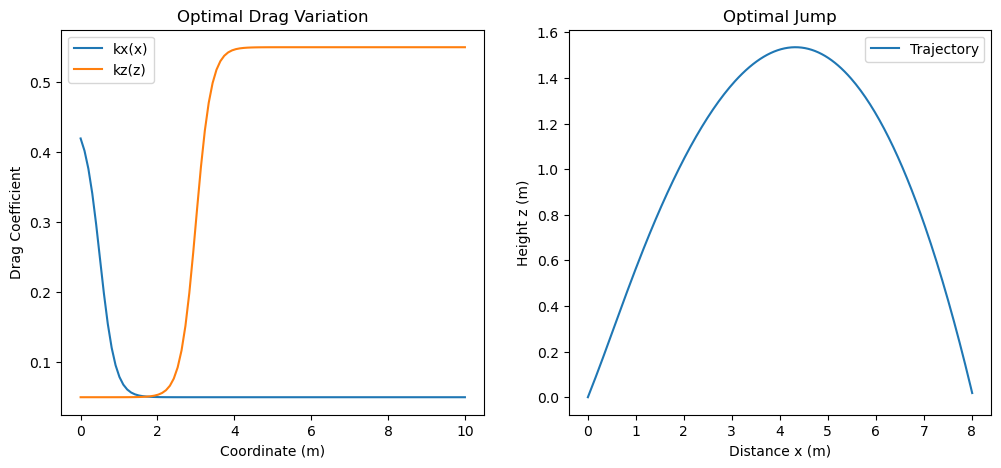

In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display, Markdown

g = 9.81
Ax, Az = 0.4, 0.5
bx, bz = 0.05, 0.05
mux, muz = -5.0, 5.0
mx = 0.5

# Logistic equation
def logistic(x, A, b, mu, m):
    return A / (1 + np.exp(-mu * (x - m))) + b

# System setup
def jump_dynamics(t, y, mz):
    x, z, vx, vz = y # Vector passed
    v = np.sqrt(vx**2 + vz**2)

    kx = logistic(x, Ax, bx, mux, mx)
    kz = logistic(z, Az, bz, muz, mz)
    
    # Acceleration equations
    dxdt = vx
    dzdt = vz
    dvxdt = -kx * vx * v
    dvzdt = -g - kz * vz * v
    
    return [dxdt, dzdt, dvxdt, dvzdt]

def hit_ground(t, y, mz):
    return y[1] # Return the z-coordinate

hit_ground.terminal = True  # Stop the integration
hit_ground.direction = -1   # (Only when going downwards)

# Optimisation
mz_range = np.arange(1, 6, 1) 
vx_range = np.arange(10.5, 12.1, 0.1)
vz_range = np.arange(5.0, 6.1, 0.5)
best_jump_distance = 0
min_vx = float('inf')
minimum_parameter = np.array([0.0, 0.0, 0.0]) # To store [vx, vz, mz]
t_eval = np.linspace(0, 2, 400)

# Loop
for mz in mz_range:
    for vx in vx_range:
        for vz in vz_range:
            y0 = [0, 0, vx, vz] # Initial conditions
            
            # Solve ODE
            sol = solve_ivp(jump_dynamics, [0, 2], y0, args=(mz,), t_eval=t_eval, events=hit_ground)
            final_x = sol.y[0][-1]
            
            # Check criteria
            if final_x > 8.0: # for valid jumps
                if vx < min_vx: # is it the most efficient so far?
                    min_vx = vx  # then store it
                    minimum_parameter = np.array([vx, vz, mz])

# Plotting as a function so I can fold it for my sanity
def Plotting():
    opt_vx, opt_vz, opt_mz = minimum_parameter
    # Re-run for plotting
    y0_opt = [0, 0, opt_vx, opt_vz]
    sol_opt = solve_ivp(jump_dynamics, [0, 2], y0_opt, args=(opt_mz,), t_eval=t_eval, events=hit_ground)
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Drag Coefficients
    s = np.linspace(0, 10, 100)
    kx_vals = logistic(s, Ax, bx, mux, mx)
    kz_vals = logistic(s, Az, bz, muz, opt_mz)
    
    ax[0].plot(s, kx_vals, label='kx(x)')
    ax[0].plot(s, kz_vals, label='kz(z)')
    ax[0].set_xlabel('Coordinate (m)')
    ax[0].set_ylabel('Drag Coefficient')
    ax[0].set_title('Optimal Drag Variation')
    ax[0].legend()
    
    # Plot 2: Trajectory
    ax[1].plot(sol_opt.y[0], sol_opt.y[1], label="Trajectory")
    ax[1].set_xlabel('Distance x (m)')
    ax[1].set_ylabel('Height z (m)')
    ax[1].set_title('Optimal Jump')
    ax[1].legend()

    display(Markdown(f"Best Parameters: $v_x = {opt_vx:.1f}, \\; v_z = {opt_vz:.1f}, \\; m_z = {opt_mz:.1f}$"))
    duration = sol_opt.t[-1]
    print(f"The jump took {duration:.3f} seconds")
    plt.savefig("TrajectSpeed")
    plt.show()

Plotting()